# Customer Churn Prediction

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
from sklearn.metrics import(
accuracy_score, 
confusion_matrix,
classification_report,
roc_curve,
roc_auc_score)


In [4]:
df= pd.read_csv("/Users/dineshkqryadav97gmail.com/Downloads/Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
#checking rows and columns size 
df.shape

(10000, 14)

df.describe()

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
###Data Cleaning
df.drop(['RowNumber', 'CustomerId', 'Surname',], axis = 1 ,  inplace = True)


In [10]:
df.shape

(10000, 11)

###check missing value and duplicates

In [11]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

###check categorical columns 

In [13]:
df.select_dtypes(include='object').columns

Index(['Geography', 'Gender'], dtype='object')

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Geography'] = le.fit_transform(df['Geography'])

### Note :- Gender has changed with numerical value.
### Female = 0;
### Male = 1;

In [16]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1
9999,792,0,0,28,4,130142.79,1,1,0,38190.78,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


### churn distribution 

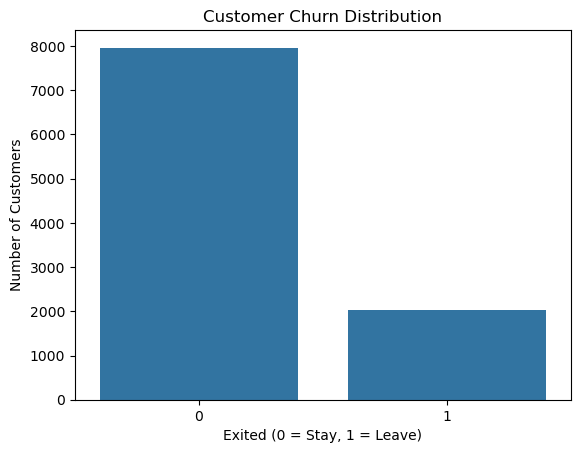

In [19]:
sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")

plt.xlabel("Exited (0 = Stay, 1 = Leave)")

plt.ylabel("Number of Customers")

plt.show()

Gender Distribution

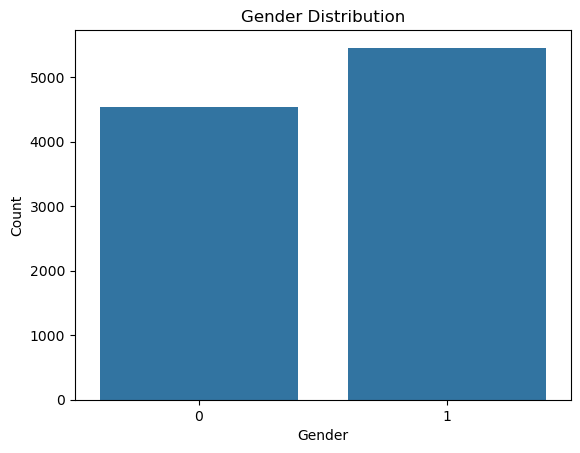

In [20]:
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

#geography Distribuiton 

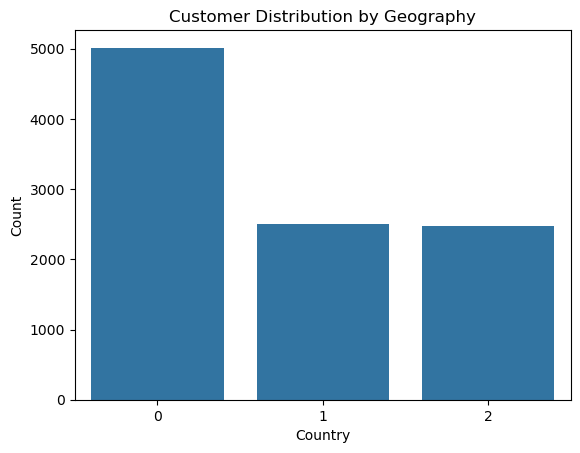

In [21]:


sns.countplot(x='Geography', data=df)

plt.title("Customer Distribution by Geography")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

###Age Distribution 

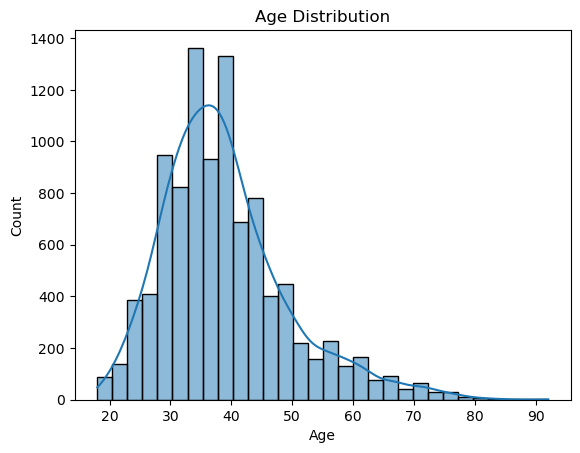

In [22]:
sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

Credit Score Distribution

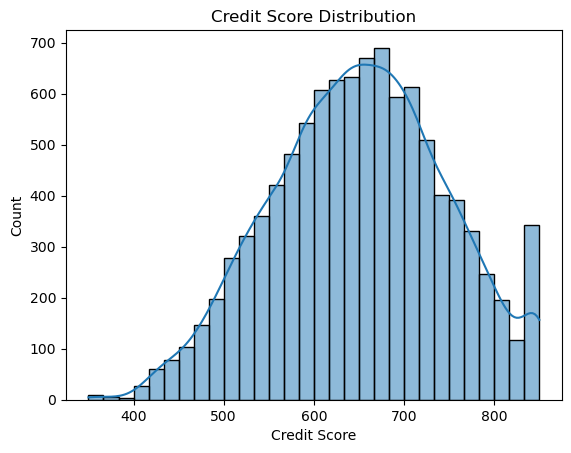

In [23]:
sns.histplot(df["CreditScore"], bins=30, kde=True)

plt.title("Credit Score Distribution")

plt.xlabel("Credit Score")

plt.ylabel("Count")

plt.show()


Balance Distribution 

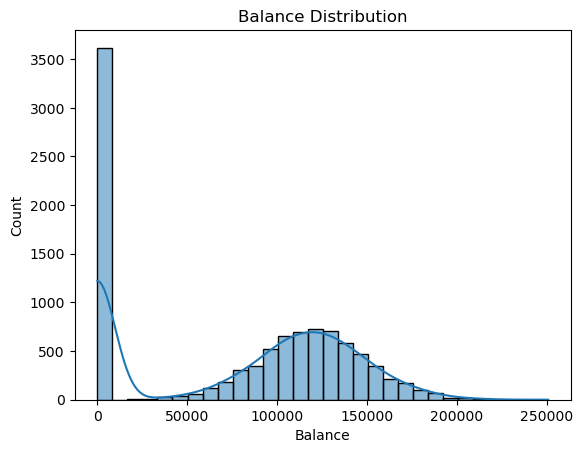

In [24]:
sns.histplot(df["Balance"], bins=30, kde=True)

plt.title("Balance Distribution")

plt.xlabel("Balance")

plt.ylabel("Count")

plt.show()

Estimated Salary Distribution 

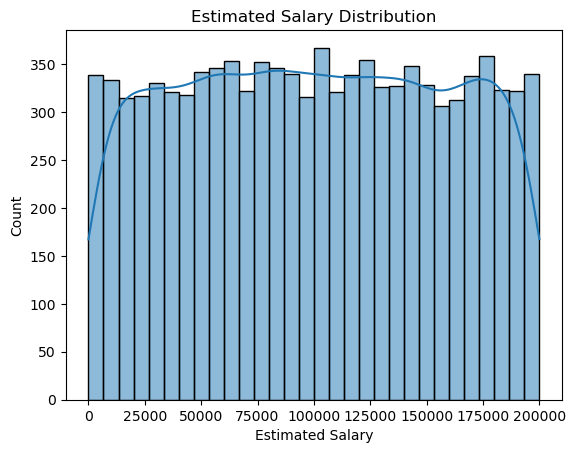

In [25]:
sns.histplot(df["EstimatedSalary"], bins=30, kde=True)

plt.title("Estimated Salary Distribution")

plt.xlabel("Estimated Salary")

plt.ylabel("Count")

plt.show()

In [26]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [27]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

#Active Member vs Churn(orange) or stayed(blue)
Among inactive customers represented(0), how many stayed and how many churned?
Among active customers represented (1), how many stayed and how many churned?

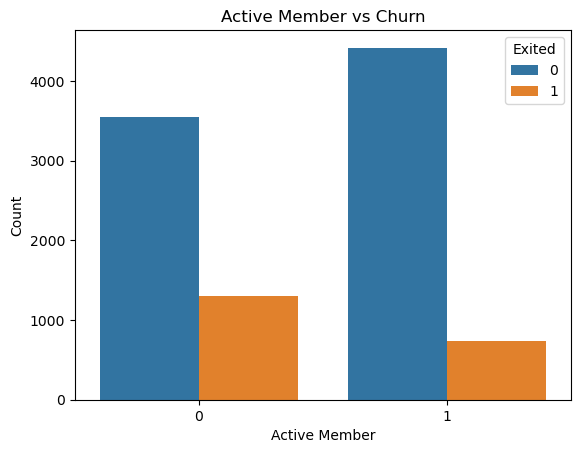

In [28]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title("Active Member vs Churn")

plt.xlabel("Active Member")

plt.ylabel("Count")

plt.show()

Number of Product vs Churn

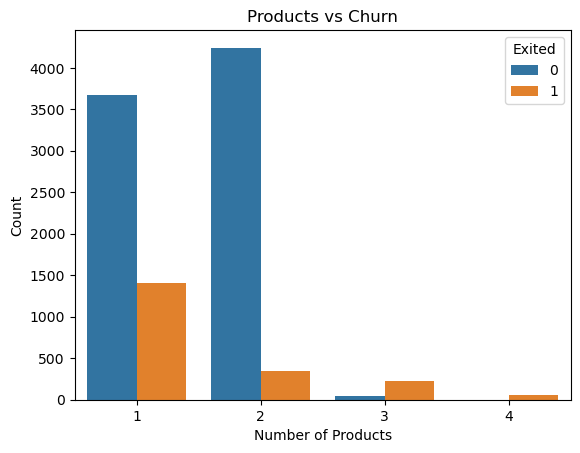

In [29]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)

plt.title("Products vs Churn")

plt.xlabel("Number of Products")

plt.ylabel("Count")

plt.show()

#Correlation Heatmap

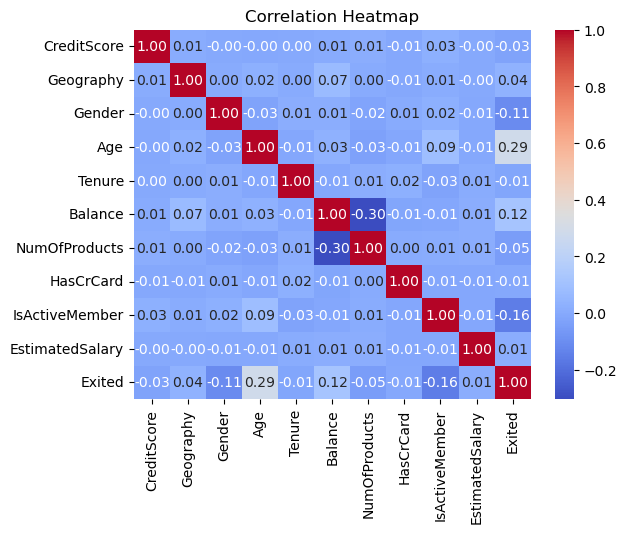

In [30]:
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

# Feature Selection 

In [31]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [32]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [33]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

# Train test split 

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state=42)

In [35]:
X_train.shape

(8000, 10)

In [36]:
X_test.shape

(2000, 10)

In [37]:
y_train.shape

(8000,)

In [38]:
y_test.shape

(2000,)

# Feature Scaling 

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [40]:
X_train_scaled[:5]

array([[ 0.35649971, -0.9055496 ,  0.91324755, -0.6557859 ,  0.34567966,
        -1.21847056,  0.80843615,  0.64920267,  0.97481699,  1.36766974],
       [-0.20389777,  0.30164867,  0.91324755,  0.29493847, -0.3483691 ,
         0.69683765,  0.80843615,  0.64920267,  0.97481699,  1.6612541 ],
       [-0.96147213,  1.50884694,  0.91324755, -1.41636539, -0.69539349,
         0.61862909, -0.91668767,  0.64920267, -1.02583358, -0.25280688],
       [-0.94071667, -0.9055496 , -1.09499335, -1.13114808,  1.38675281,
         0.95321202, -0.91668767,  0.64920267, -1.02583358,  0.91539272],
       [-1.39733684, -0.9055496 ,  0.91324755,  1.62595257,  1.38675281,
         1.05744869, -0.91668767, -1.54035103, -1.02583358, -1.05960019]])

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
lr = LogisticRegression(random_state=42)

In [43]:
#training the model 
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred_lr = lr.predict(X_test_scaled)

In [45]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

"Logistic Regression Accuracy:", accuracy_lr

('Logistic Regression Accuracy:', 0.8155)

# confusion matrix

In [46]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[1559,   48],
       [ 321,   72]])

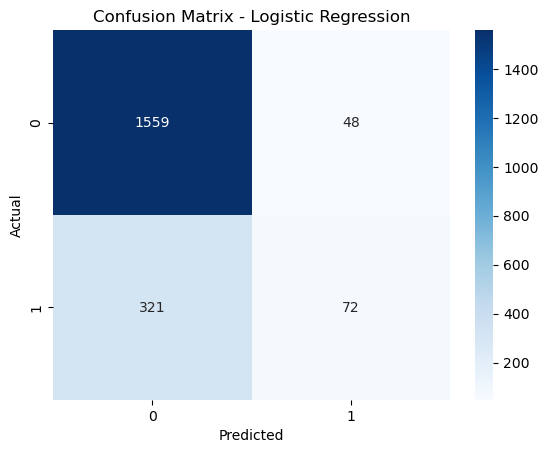

In [47]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [48]:
# classification report 
classification_report(y_test, y_pred_lr)

'              precision    recall  f1-score   support\n\n           0       0.83      0.97      0.89      1607\n           1       0.60      0.18      0.28       393\n\n    accuracy                           0.82      2000\n   macro avg       0.71      0.58      0.59      2000\nweighted avg       0.78      0.82      0.77      2000\n'

# ROC- AUC SCORE

In [49]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score :", roc)

ROC-AUC Score : 0.7635662044712144


# ROC CURVE

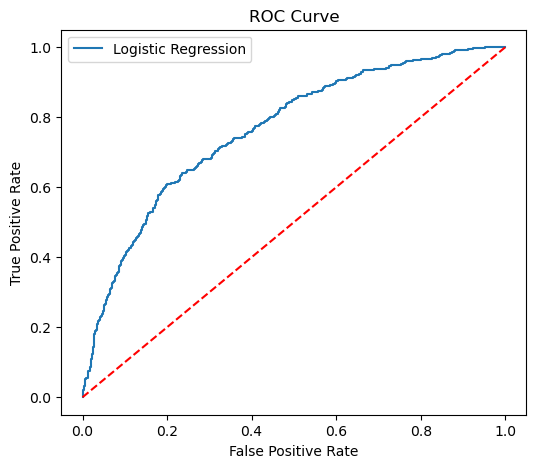

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Random Forest 

In [51]:
rf = RandomForestClassifier(random_state=42)

In [52]:
#Train the model
#Random Forest uses the original training data, not the scaled data.
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
#predict 
y_pred_rf = rf.predict(X_test)

In [54]:
# Accuracy 
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8645


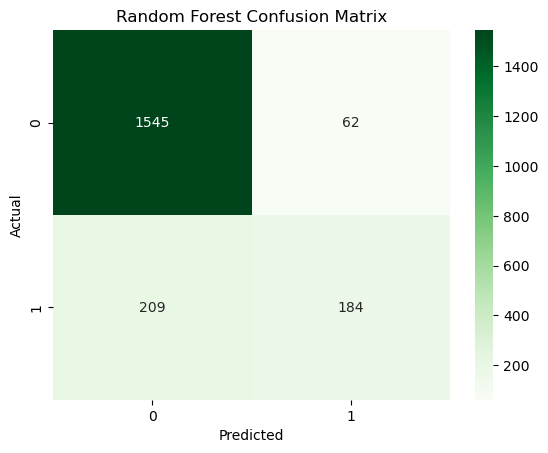

In [55]:
#confusion matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [56]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [57]:
#ROC-AUC SCORE 
y_prob_rf = rf.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", roc_rf)

ROC-AUC Score: 0.856196886712237


# GRADIENT BOOSTING 

In [58]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.866


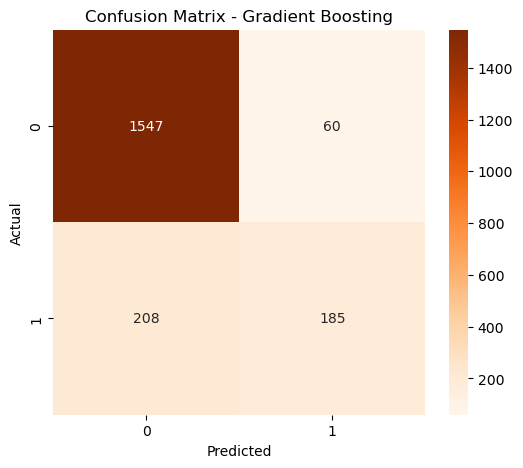

In [59]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(cm_gb,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
print(classification_report(y_test, y_pred_gb))


              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [61]:
y_prob_gb = gb.predict_proba(X_test)[:,1]

roc_gb = roc_auc_score(y_test, y_prob_gb)

print("ROC-AUC Score:", roc_gb)

ROC-AUC Score: 0.8708639523965602


In [62]:
#Compare Models
#Now all three accuracy variables

In [63]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_gb
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.8155
1,Random Forest,0.8645
2,Gradient Boosting,0.8660


In [64]:
import pickle 

In [65]:
with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(gb, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [66]:
with open("customer_churn_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model Loaded Successfully!")

Model Loaded Successfully!


#Predict New Customer
#Now we'll test our saved model with a sample customer.
#if the customer get the pridiction value is 0 it means he wants to stay or he get pridiction value is 1 means he wants to leave 

In [109]:
sample_customer = X.iloc[[18]]

sample_customer

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
18,587,2,1,45,6,0.0,1,0,0,158684.81


In [110]:
prediction = loaded_model.predict(sample_customer)

print(prediction)

[1]


In [111]:
if prediction[0] == 1:
    print("Customer is likely to CHURN (Leave)")
else:
    print("Customer is likely to STAY")

Customer is likely to CHURN (Leave)


#above we are testing the model where 12no. customer get the predicted value is 0 means customer is likely to STAY.
#If he get 1 then custeomer get likly to LEAVE 

In [89]:
probability = loaded_model.predict_proba(sample_customer)

print(probability)

[[0.75893478 0.24106522]]


In [90]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_gb
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,Gradient Boosting,0.8660
1,Random Forest,0.8645
0,Logistic Regression,0.8155


# # Conclusion

# In this project, three machine learning algorithms were used to predict customer churn.

# - Logistic Regression achieved an accuracy of approximately 81%.
# - Random Forest achieved an accuracy of approximately 86%.
# - Gradient Boosting achieved the highest accuracy of approximately 87%.

# Based on the evaluation, Gradient Boosting was selected as the best-performing model and saved using the Pickle library for future predictions.

# This model can help businesses identify customers who are likely to leave, enabling them to take proactive retention measures.